# SoSe26 – General Tasks

**Group:** XX  
**Participants:** Name 1, Name 2, ...

## Table of Contents

1. Logistics and Product Development in the Automobile Industry
   - 1.1 Data Import and Task Understanding
   - 1.2 Data Preparation
   - 1.3 Exploratory Data Analysis
   - 1.4 Distribution of Logistics Delay
   - 1.5 Mean Logistics Delay in Working Days
   - 1.6 Visualization of the Distribution
   - 1.7 Decision Tree for K7 Defects
   - 1.8 Interpretation and Conclusion
2. Data Storage in Separate Files
3. Parts T16 in Registered Vehicles
4. Attributes of the Registration Table
5. Linear Model for Mileage
6. Hit-and-Run Accident Investigation

# 1. Logistics and Product Development in the Automobile Industry

## 1.1 Data Import and Task Understanding

The objective of this task is to analyse the logistics delay of component K7.
The logistics delay is determined using the production date from the K7
component dataset and the incoming-goods receiving date (`Wareneingang`)
from the logistics-delay dataset.

According to the task description, produced goods are assumed to be issued
one day after the production date.

The analysis consists of four steps:

1. Determine the distribution of the logistics delay and justify it using
   suitable statistical goodness-of-fit tests.
2. Calculate and interpret the mean logistics delay in working days,
   excluding weekends.
3. Visualize the distribution using a Plotly histogram and density function.
4. Develop a decision-tree approach to classify whether a K7 component
   is defective.

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

In [3]:
from pathlib import Path

DATA_DIR = Path("data")

print("Data folder exists:", DATA_DIR.exists())

Data folder exists: True


# 1. Logistics and Product Development in the Automobile Industry

The objective of this task is to analyse the logistics delay for component K7.

For this analysis, the production date (`Produktionsdatum`) from
`Komponente_K7.csv` and the incoming-goods date (`Wareneingang`) from
`Logistikverzug_K7.csv` are required.

The two datasets are linked using the common `IDNummer`.

In [4]:
k7_component = pd.read_csv(
    DATA_DIR / "Komponente_K7.csv",
    sep=";"
)

k7_logistics = pd.read_csv(
    DATA_DIR / "Logistikverzug_K7.csv",
    sep=',',
    engine="python"
)

print("K7 component:", k7_component.shape)
print("K7 logistics:", k7_logistics.shape)

K7 component: (306490, 6)
K7 logistics: (306490, 6)


## 1.1 Linking the K7 production and logistics data

Both datasets contain an `IDNummer` that identifies the K7 component.
We use this identifier to connect the production information with the
corresponding logistics information.

Only records that are present in both datasets are retained.

In [5]:
k7 = k7_component.merge(
    k7_logistics,
    on="IDNummer",
    how="inner",
    suffixes=("_production", "_logistics")
)

print("K7 dataset after merging:", k7.shape)

K7 dataset after merging: (306490, 11)


## 1.2 Calculating the logistics delay

The logistics delay is calculated from the production date and the
incoming-goods date.

Because the task states that produced goods are issued one day after
production, one day is added to the production date before calculating
the delay.

In [6]:
k7["Produktionsdatum"] = pd.to_datetime(k7["Produktionsdatum"])
k7["Wareneingang"] = pd.to_datetime(k7["Wareneingang"])

k7["Logistics_delay"] = (
    k7["Wareneingang"] - k7["Produktionsdatum"]
).dt.days - 1

display(
    k7[
        [
            "IDNummer",
            "Produktionsdatum",
            "Wareneingang",
            "Logistics_delay"
        ]
    ].head()
)

,IDNummer,Produktionsdatum,Wareneingang,Logistics_delay
0,K7-114-1142-1,2008-11-12,2008-11-19,6
1,K7-114-1142-2,2008-11-12,2008-11-19,6
2,K7-114-1142-3,2008-11-13,2008-11-20,6
3,K7-114-1142-4,2008-11-13,2008-11-20,6
4,K7-114-1142-5,2008-11-13,2008-11-19,5


### 1a. Distribution of the logistics delay

The next step is to determine which probability distribution describes the
logistics delay most appropriately.

First, the distribution of the calculated delays is examined visually.
Then, suitable probability distributions are fitted and compared using
statistical goodness-of-fit tests.

The distribution with the best statistical fit will be selected to
describe the logistics delay.

In [7]:
delay = k7["Logistics_delay"].dropna()

In [8]:
distributions = {
    "Normal": stats.norm,
    "Exponential": stats.expon,
    "Gamma": stats.gamma,
    "Lognormal": stats.lognorm
}

results = []

for name, distribution in distributions.items():
    parameters = distribution.fit(delay)

    statistic, p_value = stats.kstest(
        delay,
        distribution.cdf,
        args=parameters
    )

    results.append({
        "Distribution": name,
        "KS statistic": statistic,
        "p-value": p_value
    })

results = pd.DataFrame(results)

display(results.sort_values("p-value", ascending=False))

,Distribution,KS statistic,p-value
0,Normal,0.230772,0.0
1,Exponential,0.449775,0.0
2,Gamma,0.208296,0.0
3,Lognormal,0.209612,0.0


### Comparison of the fitted distributions

The Kolmogorov–Smirnov test shows that the Gamma distribution has the
smallest KS statistic among the tested distributions. However, all
p-values are effectively zero, which is expected to some extent with
the very large sample size.

Therefore, the KS test alone is not sufficient to claim that the data
follow a theoretical distribution exactly. The fitted distributions are
also compared visually with the observed logistics-delay data.

In [9]:
fig = px.histogram(
    x=delay,
    histnorm="probability density",
    nbins=50,
    title="Distribution of Logistics Delay"
)

fig.update_layout(
    xaxis_title="Logistics delay (days)",
    yaxis_title="Density"
)

fig.show()

In [10]:
gamma_parameters = stats.gamma.fit(delay)
lognormal_parameters = stats.lognorm.fit(delay)

x = np.linspace(delay.min(), delay.max(), 500)

fig = px.histogram(
    x=delay,
    histnorm="probability density",
    nbins=50,
    opacity=0.6,
    title="Logistics Delay with Fitted Distributions"
)

fig.add_scatter(
    x=x,
    y=stats.gamma.pdf(x, *gamma_parameters),
    mode="lines",
    name="Gamma"
)

fig.add_scatter(
    x=x,
    y=stats.lognorm.pdf(x, *lognormal_parameters),
    mode="lines",
    name="Lognormal"
)

fig.update_layout(
    xaxis_title="Logistics delay (days)",
    yaxis_title="Density"
)

fig.show()

### Conclusion

The logistics delay is right-skewed, with most observations concentrated
between approximately 4 and 8 days and a longer tail towards higher delay
values.

Four probability distributions were compared using the Kolmogorov-Smirnov
test: Normal, Exponential, Gamma and Lognormal. The Gamma distribution
produced the smallest KS statistic (0.2083), followed very closely by the
Lognormal distribution (0.2096). The Exponential distribution showed the
poorest fit.

Although all p-values were effectively zero, which means that none of the
tested distributions can be regarded as an exact representation of the
large dataset, the Gamma distribution provides the best approximation
among the tested alternatives.

Therefore, the Gamma distribution is selected as the most suitable
approximation for the logistics-delay data.

### 1b. Average logistics delay in working days

For the calculation of the average logistics delay, weekends are excluded.
The first day is treated as a working day, as specified in the task.

The working-day delay is calculated for every K7 component and the average
of these values is then determined.

In [11]:
k7["Working_days_delay"] = k7.apply(
    lambda row: len(
        pd.bdate_range(
            row["Produktionsdatum"],
            row["Wareneingang"]
        )
    ) - 1,
    axis=1
)

average_working_days = k7["Working_days_delay"].mean()

print("Average logistics delay:", average_working_days, "working days")

Average logistics delay: 4.7715912427811675 working days


### Interpretation

The mean logistics delay is approximately **4.77 working days**.

This means that, on average, a K7 component takes about 4.8 working days
between the assumed issue after production and its receipt by the OEM.

The mean provides a simple summary of the logistics performance. However,
it can be influenced by unusually long or short delivery times. Possible
alternatives would therefore be the median, which is more robust to
extreme values, or additional measures such as the standard deviation and
quantiles to describe the variability of the logistics delay.

### 1c. Visualization of the logistics delay

The logistics delay is visualized using a histogram and the fitted Gamma
density function.

A bin width of 1 day was selected because the logistics delay is measured
in days. This allows each daily delay to be represented clearly while
avoiding unnecessarily small or large bins. The histogram is normalized
to probability density so that it can be compared directly with the
fitted Gamma density function.

In [12]:
gamma_parameters = stats.gamma.fit(delay)

x = np.linspace(delay.min(), delay.max(), 500)

fig = px.histogram(
    x=delay,
    histnorm="probability density",
    nbins=int(delay.max() - delay.min()) + 1,
    opacity=0.7,
    title="Distribution of Logistics Delay"
)

fig.update_traces(xbins=dict(size=1))

fig.add_scatter(
    x=x,
    y=stats.gamma.pdf(x, *gamma_parameters),
    mode="lines",
    name="Gamma density"
)

fig.update_layout(
    xaxis_title="Logistics delay (days)",
    yaxis_title="Density"
)

fig.show()

### Interpretation

The histogram shows a clearly right-skewed logistics-delay distribution,
with most observations concentrated around 4–8 days.

The fitted Gamma density follows the overall shape of the observed data
reasonably well, particularly around the main concentration and the
right-hand tail.

A bin width of one day was used because the logistics delay is measured
in whole days. This provides a direct and easily interpretable
representation of the observed delays.

## 1d. Decision tree for defective K7 components

A decision tree can be used to classify a K7 component as defective or
non-defective based on available production characteristics.

The target variable is `Fehlerhaft_production`, where 0 represents a
non-defective component and 1 represents a defective component.

Before fitting the model, the class distribution must be examined. The
K7 dataset contains 306,484 non-defective components but only 6 defective
components. This represents a very strong class imbalance.

Therefore, a decision tree can be used to demonstrate the classification
process, but its predictive performance must be interpreted carefully.
The available production characteristics are used as predictors, while
the component ID and row indices are excluded because they are identifiers
rather than meaningful explanatory variables.

In [13]:
print(k7.columns.tolist())
print()
print(k7["Fehlerhaft_production"].value_counts())

['Unnamed: 0_production', 'IDNummer', 'Produktionsdatum', 'Herstellernummer_production', 'Werksnummer_production', 'Fehlerhaft_production', 'Unnamed: 0_logistics', 'Wareneingang', 'Herstellernummer_logistics', 'Werksnummer_logistics', 'Fehlerhaft_logistics', 'Logistics_delay', 'Working_days_delay']

Fehlerhaft_production
0    306484
1         6
Name: count, dtype: int64


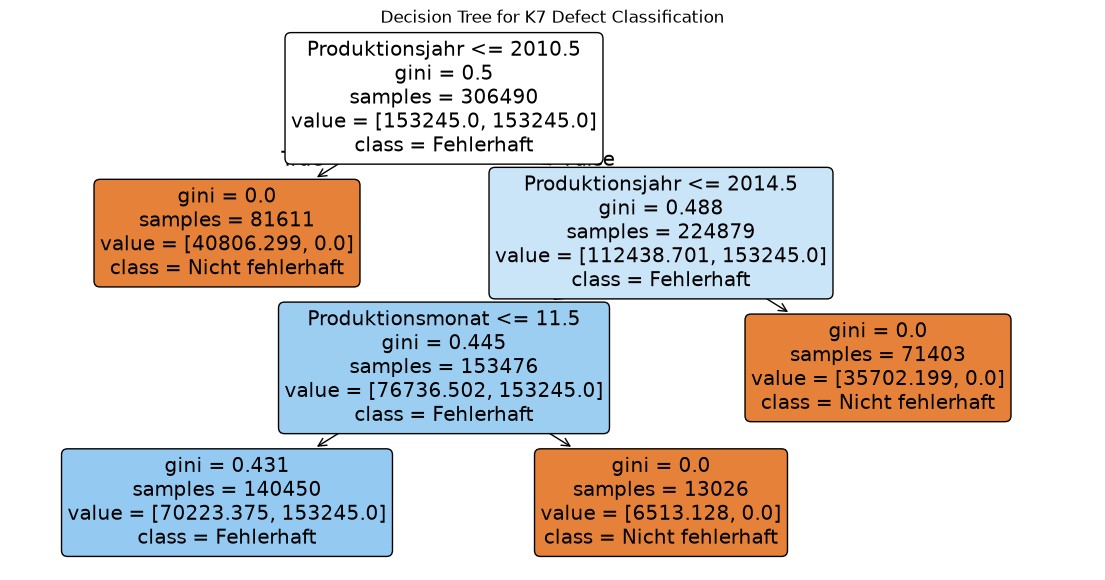

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

k7["Produktionsjahr"] = k7["Produktionsdatum"].dt.year
k7["Produktionsmonat"] = k7["Produktionsdatum"].dt.month

X = k7[
    [
        "Herstellernummer_production",
        "Werksnummer_production",
        "Produktionsjahr",
        "Produktionsmonat"
    ]
]

y = k7["Fehlerhaft_production"]

model = DecisionTreeClassifier(
    max_depth=3,
    class_weight="balanced",
    random_state=42
)

model.fit(X, y)

plt.figure(figsize=(14, 7))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Nicht fehlerhaft", "Fehlerhaft"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree for K7 Defect Classification")
plt.show()

### Interpretation

The decision tree identifies production year and production month as the
main variables used to separate defective and non-defective K7
components. The first split is based on the production year, followed by
additional splits on production year and production month.

However, the dataset contains only 6 defective components out of 306,490
observations. This represents a very strong class imbalance. To account
for this, balanced class weights were used when fitting the decision tree.

The resulting tree should therefore be interpreted with caution. The
identified splits describe patterns in the available data, but they do
not demonstrate that production date causes a component to become
defective. The very small number of defective observations also limits
the reliability and generalizability of the classification model.

## 2. Data Storage in Separate Files

Storing the available data in separate files instead of one large table has several advantages:

- **Less data duplication:** The same information does not have to be stored repeatedly in different tables.
- **Better organization:** Each table contains information about a specific topic, such as components, logistics, vehicles, or registrations.
- **Easier maintenance:** Changes can be made to one table without having to modify a very large combined table.
- **Better data consistency:** Centralized information can be maintained in one place, reducing the risk of conflicting values.
- **Smaller and more manageable datasets:** Working with separate tables can make data processing and analysis easier.
- **Flexible analysis:** The tables can be connected when needed using common identifiers.

The available tables therefore represent a typical **relational database structure**. The individual tables are related to each other through common keys or identifiers.

## 3. Parts T16 in Registered Vehicles

The goal is to determine how many T16 parts were installed in vehicles that were registered in Adelshofen.

To answer this question, the data has to be traced through the different tables. First, the T16 parts are identified. These parts are then linked to the components in which they were installed. The components are subsequently linked to vehicles. Finally, the vehicle IDs are matched with the registration data and filtered for Adelshofen.

In [16]:
zulassungen = pd.read_csv(
    "data/Zulassungen_alle_Fahrzeuge.csv",
    sep=";"
)

print("Registrations:", zulassungen.shape)
print(zulassungen.columns.tolist())

Registrations: (3204104, 4)
['Unnamed: 0', 'IDNummer', 'Gemeinden', 'Zulassung']


In [17]:
b_k_k2le2 = pd.read_csv(
    "data/Bestandteile_Komponente_K2LE2.csv",
    sep=";"
)

b_k_k2st2 = pd.read_csv(
    "data/Bestandteile_Komponente_K2ST2.csv",
    sep=";"
)

t16_components_le2 = b_k_k2le2[
    ["ID_T16", "ID_K2LE2"]
].copy()

t16_components_st2 = b_k_k2st2[
    ["ID_T16", "ID_K2ST2"]
].copy()

print("K2LE2 T16 relationships:", len(t16_components_le2))
print("K2ST2 T16 relationships:", len(t16_components_st2))

K2LE2 T16 relationships: 163769
K2ST2 T16 relationships: 655075


In [18]:
t16_components = pd.concat(
    [
        t16_components_le2,
        t16_components_st2
    ],
    ignore_index=True
)

print("Total T16-component relationships:", len(t16_components))

Total T16-component relationships: 818844


In [19]:
bestandteile_fahrzeuge_oem1_typ11 = pd.read_csv(
    "data/Bestandteile_Fahrzeuge_OEM1_Typ11.csv",
    sep=";"
)

bestandteile_fahrzeuge_oem1_typ12 = pd.read_csv(
    "data/Bestandteile_Fahrzeuge_OEM1_Typ12.csv",
    sep=";"
)

bestandteile_fahrzeuge_oem2_typ21 = pd.read_csv(
    "data/Bestandteile_Fahrzeuge_OEM2_Typ21.csv",
    sep=";"
)

bestandteile_fahrzeuge_oem2_typ22 = pd.read_csv(
    "data/Bestandteile_Fahrzeuge_OEM2_Typ22.csv",
    sep=";"
)

In [20]:
standard_headers = [
    "X1",
    "ID_Karosserie",
    "ID_Schaltung",
    "ID_Sitze",
    "ID_Motor",
    "ID_Fahrzeug"
]

bestandteile_fahrzeuge_oem1_typ11.columns = standard_headers
bestandteile_fahrzeuge_oem1_typ12.columns = standard_headers
bestandteile_fahrzeuge_oem2_typ21.columns = standard_headers
bestandteile_fahrzeuge_oem2_typ22.columns = standard_headers

In [21]:
all_vehicles = pd.concat(
    [
        bestandteile_fahrzeuge_oem1_typ11,
        bestandteile_fahrzeuge_oem1_typ12,
        bestandteile_fahrzeuge_oem2_typ21,
        bestandteile_fahrzeuge_oem2_typ22
    ],
    ignore_index=True
)

print("All vehicles:", all_vehicles.shape)

All vehicles: (3204104, 6)


In [22]:
t16_components_le2 = (
    t16_components_le2["ID_K2LE2"]
    .dropna()
    .unique()
)

t16_components_st2 = (
    t16_components_st2["ID_K2ST2"]
    .dropna()
    .unique()
)

matched_vehicles = all_vehicles[
    (all_vehicles["ID_Sitze"].isin(t16_components_le2)) |
    (all_vehicles["ID_Sitze"].isin(t16_components_st2))
].copy()

print("Vehicles containing T16-related components:", len(matched_vehicles))

Vehicles containing T16-related components: 818844


In [23]:
adelshofen_vehicles = zulassungen[
    zulassungen["Gemeinden"].astype(str).str.upper() == "ADELSHOFEN"
]

print("Vehicles registered in Adelshofen:", len(adelshofen_vehicles))

Vehicles registered in Adelshofen: 132


In [24]:
vehicles_in_adelshofen = matched_vehicles[
    matched_vehicles["ID_Fahrzeug"].isin(
        adelshofen_vehicles["IDNummer"]
    )
]

print(
    "Number of T16 parts in vehicles registered in Adelshofen:",
    len(vehicles_in_adelshofen)
)

Number of T16 parts in vehicles registered in Adelshofen: 48


## 4. Attributes of the Registration Table

The registration table contains information about the vehicle ID,
the municipality where the vehicle is registered, and the registration date.

The data types of the attributes are examined below.

In [25]:
print(zulassungen.dtypes)

Unnamed: 0    int64
IDNummer        str
Gemeinden       str
Zulassung       str
dtype: object


| Attribute | Data type | Description |
|---|---|---|
| `IDNummer` | `str` | Text data used to identify the vehicle. |
| `Gemeinden` | `str` | Text data containing the municipality where the vehicle is registered. |
| `Zulassung` | `str` | Text data representing the vehicle's registration date. |

Although `Zulassung` represents a date, it is stored as a string in the
provided dataset. It could be converted to a datetime data type if
date-based calculations or analysis were required.

## 5. Linear Model for Mileage

The aim is to investigate which variables are related to the mileage of
OEM1 Type11 vehicles and to derive recommendations for OEM1.

The dataset `Fahrzeuge_OEM1_Typ11_Fehleranalyse` contains information about
the vehicles, their characteristics, mileage and whether a vehicle is
classified as defective.

First, the identifier columns are removed because they do not provide
useful explanatory information. The remaining variables are prepared for
the modelling process.

In [26]:
fahrzeuge_oem1 = pd.read_csv(
    "data/Fahrzeuge_OEM1_Typ11_Fehleranalyse.csv"
)

print(fahrzeuge_oem1.shape)
display(fahrzeuge_oem1.head())

(198069, 11)


,Unnamed: 0,X,X1,ID_Fahrzeug,Herstellernummer,Werksnummer,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung,days,fuel,engine
0,9,9,9,11-1-11-9,1,11,2010-03-16,34824.319559,1493.150761,4.003670,small
1,11,11,11,11-1-11-11,1,11,2010-03-16,74217.428309,1044.462231,11.042487,large
2,13,13,13,11-1-11-13,1,11,2010-03-16,32230.699639,749.669810,3.579117,small
3,15,15,15,11-1-11-15,1,11,2010-03-16,44885.783551,858.688003,4.666801,small
4,37,37,37,11-1-11-37,1,11,2010-03-17,86348.329866,1478.204174,4.634381,small


### Data preparation

The dataset contains identifiers as well as variables describing the
vehicles and their operating conditions.

The identifier columns are not suitable explanatory variables for the
linear model, so they are removed before modelling. The remaining
variables are then prepared for the analysis.

In [27]:
print(fahrzeuge_oem1.columns.tolist())

['Unnamed: 0', 'X', 'X1', 'ID_Fahrzeug', 'Herstellernummer', 'Werksnummer', 'Fehlerhaft_Datum', 'Fehlerhaft_Fahrleistung', 'days', 'fuel', 'engine']


In [28]:
fahrzeuge_oem1_model = fahrzeuge_oem1.drop(
    columns=[
        "Unnamed: 0",
        "X",
        "X1",
        "ID_Fahrzeug"
    ]
).copy()

print(fahrzeuge_oem1_model.shape)
display(fahrzeuge_oem1_model.head())

(198069, 7)


,Herstellernummer,Werksnummer,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung,days,fuel,engine
0,1,11,2010-03-16,34824.319559,1493.150761,4.003670,small
1,1,11,2010-03-16,74217.428309,1044.462231,11.042487,large
2,1,11,2010-03-16,32230.699639,749.669810,3.579117,small
3,1,11,2010-03-16,44885.783551,858.688003,4.666801,small
4,1,11,2010-03-17,86348.329866,1478.204174,4.634381,small


### Feature preparation

The date of the defect is converted into numerical features so that it
can be used in the linear model. The engine category is also converted
into numerical variables because regression models require numerical
input.

In [29]:
fahrzeuge_oem1_model["Fehlerhaft_Datum"] = pd.to_datetime(
    fahrzeuge_oem1_model["Fehlerhaft_Datum"]
)

fahrzeuge_oem1_model["Fehlerhaft_Jahr"] = (
    fahrzeuge_oem1_model["Fehlerhaft_Datum"].dt.year
)

fahrzeuge_oem1_model["Fehlerhaft_Monat"] = (
    fahrzeuge_oem1_model["Fehlerhaft_Datum"].dt.month
)

fahrzeuge_oem1_model = pd.get_dummies(
    fahrzeuge_oem1_model,
    columns=["engine"],
    drop_first=True
)

fahrzeuge_oem1_model = fahrzeuge_oem1_model.drop(
    columns=["Fehlerhaft_Datum"]
)

print(fahrzeuge_oem1_model.columns.tolist())
display(fahrzeuge_oem1_model.head())

['Herstellernummer', 'Werksnummer', 'Fehlerhaft_Fahrleistung', 'days', 'fuel', 'Fehlerhaft_Jahr', 'Fehlerhaft_Monat', 'engine_medium', 'engine_small']


,Herstellernummer,Werksnummer,Fehlerhaft_Fahrleistung,days,fuel,Fehlerhaft_Jahr,Fehlerhaft_Monat,engine_medium,engine_small
0,1,11,34824.319559,1493.150761,4.003670,2010,3,False,True
1,1,11,74217.428309,1044.462231,11.042487,2010,3,False,False
2,1,11,32230.699639,749.669810,3.579117,2010,3,False,True
3,1,11,44885.783551,858.688003,4.666801,2010,3,False,True
4,1,11,86348.329866,1478.204174,4.634381,2010,3,False,True


### Examination of the variables

Before fitting the linear model, the distributions and relationships of
the numerical variables are examined. This helps identify variables that
may require transformation and provides an initial indication of their
relationship with the mileage at which the defect occurred.

In [30]:
display(fahrzeuge_oem1_model.describe())

,Herstellernummer,Werksnummer,Fehlerhaft_Fahrleistung,days,fuel,Fehlerhaft_Jahr,Fehlerhaft_Monat
count,198069.0,198069.000000,198069.000000,198069.000000,198069.000000,198069.000000,198069.000000
mean,1.0,11.400401,44684.388895,1206.441408,4.737917,2013.714938,6.530265
std,0.0,0.489981,15506.236718,278.344811,2.386467,2.322820,3.449912
min,1.0,11.000000,17060.925341,723.001041,0.833570,2010.000000,1.000000
25%,1.0,11.000000,33096.971051,966.043781,3.020322,2012.000000,4.000000
50%,1.0,11.000000,42100.440654,1207.055831,4.220829,2014.000000,7.000000
75%,1.0,12.000000,53705.552253,1447.451112,5.891983,2016.000000,10.000000
max,1.0,12.000000,108771.548636,1686.997952,22.184767,2018.000000,12.000000


### Removing constant variables

`Herstellernummer` has the same value for every observation and therefore
cannot explain differences in the mileage at which a defect occurs.

It is removed from the modelling dataset.

In [31]:
fahrzeuge_oem1_model = fahrzeuge_oem1_model.drop(
    columns=["Herstellernummer"]
)

print(fahrzeuge_oem1_model.columns.tolist())

['Werksnummer', 'Fehlerhaft_Fahrleistung', 'days', 'fuel', 'Fehlerhaft_Jahr', 'Fehlerhaft_Monat', 'engine_medium', 'engine_small']


### Distribution of fuel consumption

The distribution of `fuel` is examined before fitting the linear model.
A strongly skewed variable may benefit from a transformation so that
the linear model can describe its relationship with the target variable
more appropriately.

In [32]:
print("Fuel skewness:", fahrzeuge_oem1_model["fuel"].skew())

Fuel skewness: 1.3555867397529922


### Transformation of fuel consumption

The `fuel` variable is positively skewed. To reduce this skewness, a
logarithmic transformation is applied before using the variable in the
linear model.

In [33]:
fahrzeuge_oem1_model["fuel_log"] = np.log(
    fahrzeuge_oem1_model["fuel"]
)

print(
    "Original fuel skewness:",
    fahrzeuge_oem1_model["fuel"].skew()
)

print(
    "Log-transformed fuel skewness:",
    fahrzeuge_oem1_model["fuel_log"].skew()
)

Original fuel skewness: 1.3555867397529922
Log-transformed fuel skewness: 0.00698762824791307


### Correlation analysis

The correlations between the numerical variables are examined to identify
which variables have a relationship with the mileage at which the defect
occurs.

The log-transformed fuel variable is used instead of the original fuel
variable because its distribution is considerably less skewed.

In [34]:
numeric_data = fahrzeuge_oem1_model[
    [
        "Fehlerhaft_Fahrleistung",
        "Werksnummer",
        "days",
        "fuel_log",
        "Fehlerhaft_Jahr",
        "Fehlerhaft_Monat"
    ]
]

display(numeric_data.corr())

,Fehlerhaft_Fahrleistung,Werksnummer,days,fuel_log,Fehlerhaft_Jahr,Fehlerhaft_Monat
Fehlerhaft_Fahrleistung,1.000000,0.001144,0.001684,0.694348,-0.005913,0.021376
Werksnummer,0.001144,1.000000,-0.000685,-0.001824,0.007721,-0.003637
days,0.001684,-0.000685,1.000000,0.003162,-0.000645,0.001958
fuel_log,0.694348,-0.001824,0.003162,1.000000,-0.001146,0.016992
Fehlerhaft_Jahr,-0.005913,0.007721,-0.000645,-0.001146,1.000000,-0.122639
Fehlerhaft_Monat,0.021376,-0.003637,0.001958,0.016992,-0.122639,1.000000


### Preparation for the linear model

The target variable is the mileage at which the defect occurs,
`Fehlerhaft_Fahrleistung`.

The remaining variables are used as explanatory variables. The
log-transformed fuel consumption is used instead of the original
`fuel` variable because the log transformation substantially reduced
its skewness.

In [35]:
X = fahrzeuge_oem1_model[
    [
        "Werksnummer",
        "days",
        "fuel_log",
        "Fehlerhaft_Jahr",
        "Fehlerhaft_Monat",
        "engine_medium",
        "engine_small"
    ]
]

y = fahrzeuge_oem1_model["Fehlerhaft_Fahrleistung"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (198069, 7)
y shape: (198069,)


### Train-test split

The dataset is divided into a training set and a test set. The training
data are used to estimate the linear regression model, while the test
data are used to evaluate its predictive performance on previously unseen
observations.

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

Training data: (158455, 7)
Test data: (39614, 7)


### Linear regression model

A linear regression model is fitted using the training data. The model
predicts the mileage at which a defect occurs based on the selected
vehicle and operating variables.

In [37]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

y_pred = linear_model.predict(X_test)

print("Model fitted successfully.")

Model fitted successfully.


### Evaluation of the linear model

The model is evaluated on the test data using the coefficient of
determination (R²) and the root mean squared error (RMSE).

R² measures how much of the variation in the defect mileage is explained
by the model. RMSE measures the typical size of the prediction error in
kilometres.

In [38]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("R²:", r2)
print("RMSE:", rmse, "km")

R²: 0.49338730741288817
RMSE: 11076.930271592171 km


### Regression coefficients

The coefficients of the linear regression model are examined to determine
how the explanatory variables are associated with the predicted mileage
at which a defect occurs.

In [39]:
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients = coefficients.sort_values(
    "Coefficient",
    ascending=False
)

display(coefficients)

,Variable,Coefficient
2,fuel_log,20131.848963
0,Werksnummer,64.018158
4,Fehlerhaft_Monat,46.877276
1,days,-0.067899
3,Fehlerhaft_Jahr,-16.881485
5,engine_medium,-4452.316350
6,engine_small,-7263.523559


### Actual versus predicted mileage

The actual defect mileage is compared with the mileage predicted by the
linear regression model. This helps to assess how closely the predictions
follow the observed values.

In [40]:
fig = px.scatter(
    x=y_test,
    y=y_pred,
    labels={
        "x": "Actual defect mileage (km)",
        "y": "Predicted defect mileage (km)"
    },
    title="Actual vs. Predicted Defect Mileage"
)

fig.show()

In [41]:
fig = px.scatter(
    x=y_test,
    y=y_pred,
    labels={
        "x": "Actual defect mileage (km)",
        "y": "Predicted defect mileage (km)"
    },
    title="Actual vs. Predicted Defect Mileage"
)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

fig.add_scatter(
    x=[min_value, max_value],
    y=[min_value, max_value],
    mode="lines",
    name="Ideal prediction"
)

fig.show()

### XGBoost Regressor

An XGBoost regression model is fitted to the same training data and
compared with the linear regression model. XGBoost can capture
non-linear relationships between the explanatory variables and the
defect mileage.

In [42]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb
    )
)

print("XGBoost R²:", r2_xgb)
print("XGBoost RMSE:", rmse_xgb, "km")

XGBoost R²: 0.4993886411562535
XGBoost RMSE: 11011.126156464657 km


### Feature importance

The feature importance of the XGBoost model is examined to identify
which variables contribute most to the prediction of the mileage at
which a defect occurs.

In [43]:
feature_importance = pd.DataFrame({
    "Variable": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Variable,Importance
2,fuel_log,0.732565
5,engine_medium,0.229050
3,Fehlerhaft_Jahr,0.012160
6,engine_small,0.007440
4,Fehlerhaft_Monat,0.007435
1,days,0.005803
0,Werksnummer,0.005548


### XGBoost feature importance

The feature importance values are visualized to make it easier to
compare the contribution of the explanatory variables to the XGBoost
predictions.

In [44]:
fig = px.bar(
    feature_importance,
    x="Importance",
    y="Variable",
    orientation="h",
    title="XGBoost Feature Importance"
)

fig.show()

### Interpretation and recommendation

Both regression models show that fuel consumption is the most important
variable for predicting the mileage at which a defect occurs. The XGBoost
model confirms this result, with fuel consumption having substantially
higher feature importance than the other variables.

The XGBoost model performs slightly better than the linear regression,
with an R² of 0.4994 compared with 0.4934 and an RMSE of 11,011 km
compared with 11,077 km.

However, the improvement is relatively small. Therefore, the linear
regression already provides a reasonable baseline, while XGBoost can
capture some additional non-linear relationships.

For OEM1, fuel consumption should receive particular attention when
analysing defect mileage. The engine type also appears relevant,
especially for vehicles classified as having a medium-sized engine.
The other variables included in the model have comparatively little
predictive importance.

## 6. Hit-and-Run Accident Investigation

On 11.08.2010, a hit-and-run accident occurred. The license plate of
the vehicle is unknown. The objective is to identify the vehicle
containing the body part `K5-112-1122-79` and determine where it was
registered.

In [58]:
bestandteile = pd.read_csv(
    "data/Bestandteile_Fahrzeuge_OEM1_Typ12.csv",
    sep=";"
)

print(bestandteile.shape)
print(bestandteile.columns.tolist()
)

(408096, 6)
['Unnamed: 0', 'ID_Karosserie', 'ID_Schaltung', 'ID_Sitze', 'ID_Motor', 'ID_Fahrzeug']


In [60]:
bestandteil = bestandteile[
    bestandteile[
        ["ID_Karosserie", "ID_Schaltung", "ID_Sitze", "ID_Motor"]
    ].eq("K5-112-1122-79").any(axis=1)
]

display(bestandteil)

,Unnamed: 0,ID_Karosserie,ID_Schaltung,ID_Sitze,ID_Motor,ID_Fahrzeug
81,82,K5-112-1122-79,K3SG1-105-1051-129,K2ST1-109-1092-519,K1BE1-104-1041-409,12-1-12-82


In [62]:
print(zulassungen.columns.tolist())

['Unnamed: 0', 'IDNummer', 'Gemeinden', 'Zulassung']


In [63]:
t6_vehicle = zulassungen[
    zulassungen["IDNummer"] == "12-1-12-82"
]

display(t6_vehicle)

,Unnamed: 0,IDNummer,Gemeinden,Zulassung
223,82,12-1-12-82,ASCHERSLEBEN,2009-01-02


### Result

The body part `K5-112-1122-79` is associated with vehicle
`12-1-12-82`. According to the registration data, this vehicle was
registered in **ASCHERSLEBEN** on 02.01.2009.

Therefore, the vehicle involved in the hit-and-run accident was
registered in **ASCHERSLEBEN**.